# Design Process

Based off [of two forumalas:](https://studylib.net/doc/18748913/steel-sheet-piling-design-manual)
<center>
<img src="res/imgs/Lateral Pressure From Pt Load.png">
<img src="res/imgs/Lateral Pressure From Pt Load 2.png">
<img src="res/imgs/Foundations_Fig_11.jpg">
</center>

## Formulas

In case the above images aren't loading correctly, the five formulas primarily being considered are as follows:



$$\sigma_H = 0.28 \frac{Q_\rho}{H^2} \cdot \frac{n^2}{(0.16 + n^2)^3}\ (for\ m \leq 0.4) \tag{1}$$
$$P_H = 0.78 \frac{Q_\rho}{H} \tag{2}$$
$$\sigma_H = 1.77 \frac{Q_\rho}{H^2} \cdot \frac{m^2 n^2}{(m^2 + n^2)^3} (for\ m > 0.4) \tag{3}$$
$$P_H = 0.45 \frac{Q_\rho}{H} \tag{4}$$ 

and,

$$\sigma_H' = \sigma_Hcos^2(1.1\ \theta) \tag{5}$$

## Definition of Variables

The following variables are defined here and used later in the proceeding code:

$ \sigma_H $ = `sigma_h` - The stress at a given location `(x, z)` behind the wall due to live load lateral surcharge

$ Q_\sigma $ = `Q_sigma` - Load being applied to the soil at the top of the wall

$ H $ = `H` - Height from the base of the wall where the load is being applied

$ n $ = `n` - `0 to 1`, a factor value to determine the stress at a vertical point `z`

$ m $ = `m` - a factor value to relate the distance of the applied load from the wall `x` to the height of the wall `H` the formulas adjust if the `m` value is larger than 0.4

$ x $ = `x` - Distance from the wall the load is applied (Used to derive `m`)

$ z $ = `z` - height at which the stress is being calculated (Used to derive `n`)

$ P_H $ = `P_H` - The maximum pressure behind the wall

$ L $ = `L` - The height of the highest pressure, defined by `.59H` if `m <= 0.4` or `.48H` if `m > 0.4`.


```python
sigma_h
p_h
```

To determine the pressure to the left and right of the centerline of the point of maximum pressure, Boussinesqs equation can be applied in the horizontal direction via the above equation 5.

In [1]:
# Import packages
import pint
import numpy as np

units = pint.UnitRegistry()

In [2]:
# Define the load
Q_sigma = 80 * units.kips

# Height of the wall
H = 10 * units.ft

# Define the Distance to wall load is applied (will be demonstrated as a loop later)
x = 4 * units.ft

In [3]:
# Calculate `m` and `n` factors
m = x/H
print(f"{m=:}")

# Using z = H-L to get height of maximum pressure
L = .59*H if m > 0.4 else .48*H
print(f"{L=:}")
z = H-L
print(f"{z=:}")

# Define 
n = z / H
print(f"{n=:}")

m=0.4 dimensionless
L=4.8 foot
z=5.2 foot
n=0.52 dimensionless


In [4]:
# Calculate P_H (Max Pressure) (Seems inaccurate)
P_H = (0.45 * Q_sigma) / H if m > 0.4 else 0.78 * Q_sigma / H
print(f"{P_H=:}")

P_H=6.24 kip / foot


In [5]:
# Calc sigma_h for each value of z and graph the result
def calc_sigma_h_values(Q_sigma, H, x, H_n=100):
    """
    Function that calculates the live load lateral surcharge along the height of a given wall, requires the following values:

    Q_sigma = The load being analyzed (Kips)
    H = The height of the wall (ft.)
    x = The distance back from the wall the load is applied
    H_n = The number of points to analyze along the height of the wall, defaults to 100

    Returns:
        sigma_h_values = A series of values given the live load and distance
    """
    # Perform supporting calcs, determine value of m for this distance
    m = x / H
    
    # Create a range of heights to analyze as your independent values
    height_values = [height * units.ft for height in np.round(np.arange(0, H.magnitude + (H/H_n).magnitude, (H/H_n).magnitude), 1)]
    # Defines an empty dict to create an ordered set to return the values of the calculation
    sigma_h_vals = {}

    # Run a loop to determine the value of sigma at each height value, assign both values to the return variable `sigma_h_values`
    for z in height_values:
        # Calculates `n` for the height along the wall being analyzed
        n = z / H

        # Determines which formula from Boussinesq Equations and applies it
        if m <= 0.4:
            sigma_h_vals[H-z] = 0.28 * (Q_sigma / H ** 2) * ((n**2) / ((0.16 + n ** 2) ** 3))
        else:
            sigma_h_vals[H-z] = 1.77 * (Q_sigma / H ** 2) * ((m**2 * n**2) / ((m**2 + n**2) ** 3))

    # Return the calculated values
    return sigma_h_vals

def annot_max(x,y, ax=None):
    """
    Function to find the local maximum stress of a plot and and annotate it

    x = x values of the plot (list)
    y = y values of the plot (list)
    ax = Axis of the plot
    """
    # Find max value and the y value associated with it
    xmax = max(x)
    ymax = y[np.argmax(x)]
    text= "x={:.3f}, y={:.3f}".format(xmax, ymax)
    if not ax:
        ax=plt.gca()
    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
    arrowprops=dict(arrowstyle="->",connectionstyle="angle,angleA=0,angleB=60")
    kw = dict(xycoords='data',textcoords="axes fraction",
              arrowprops=arrowprops, bbox=bbox_props, ha="right", va="top")
    ax.annotate(text, xy=(xmax, ymax), xytext=(0.94,0.96), **kw)

    return xmax, ymax

In [6]:
# Get the values of the load for a given x (Will be adjusted for true Cooper's E80 Later)
graphing_values = calc_sigma_h_values(Q_sigma, H, x)

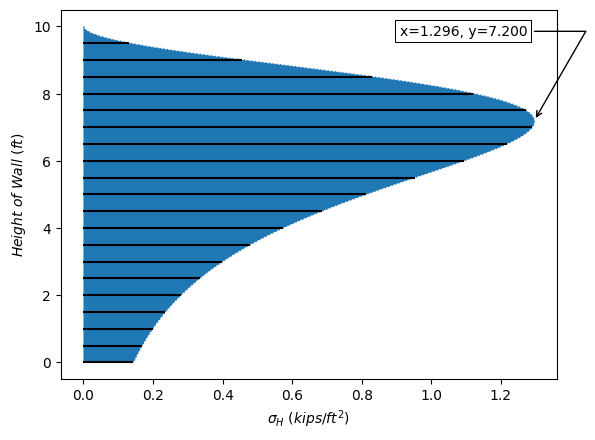

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

xs, ys = list(), list()

fig, ax = plt.subplots()

for key, value in graphing_values.items():
    ys.append(key.magnitude)
    xs.append(value.magnitude)

# Create the plot
fig = plt.plot(xs, ys, lw=1, linestyle='dotted')

# Add annotations, rectangular wall shape and fill
xmax, ymax = annot_max(xs, ys)
plt.fill_between(xs, ys)
plt.ylabel('$Height\ of\ Wall\ (ft)$')
plt.xlabel('$\sigma_H$ $(kips/ft^2)$')

plt.hlines(ys[::5], 0, xs[::5], color='black')

# Show the plot
plt.show()

# Animate the Graph to Show a Load Moving Closer to the Wall

The next cell can essentially be ignored, it's just to test that the plot to gif code is working

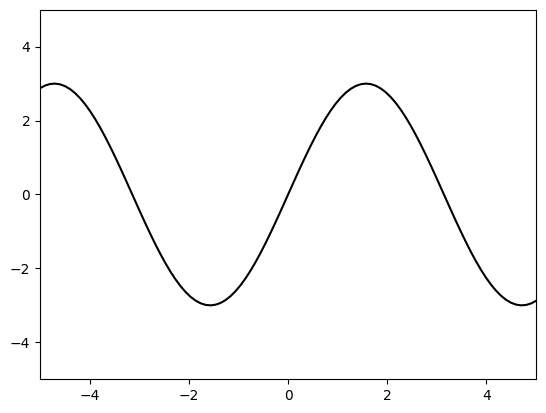

In [8]:
from matplotlib.animation import PillowWriter

fig = plt.figure()
l, = plt.plot([],[], 'k-')

plt.xlim(-5, 5)
plt.ylim(-5, 5)

def func(x):
    return np.sin(x)*3

metadata = dict(title='Live Load Lateral Surcharge Demo', artist='Dane Parks')
writer = PillowWriter(fps=15, metadata = metadata)

xlist = []
ylist = []

with writer.saving(fig, "sinWave.gif", 100):
    for xval in np.linspace(-5, 5, 100):
        xlist.append(xval)
        ylist.append(func(xval))

        l.set_data(xlist, ylist)

        writer.grab_frame()

## Using a Single Axel Load of 80 kip

In [15]:
fig, ax = plt.subplots()

metadata = dict(title='Live Load Lateral Surcharge Demo', artist='Dane Parks')
writer = PillowWriter(fps=15, metadata = metadata)

xlist = []
ylist = []

with writer.saving(fig, "Single_Axel.gif", 100):
    for xval in np.linspace(H.magnitude*2, 0, 100):
        graphing_values = calc_sigma_h_values(Q_sigma, H, xval*units.ft)
        
        xs, ys = list(), list()
    
        # Run a loop to extract this frames values from the above function call results
        for value in graphing_values:
            ys.append(value.magnitude)
            xs.append(graphing_values[value].magnitude)
        
        # Create the plot
        fig = plt.plot(xs, ys, lw=1, linestyle='dotted')
        
        # Add annotations, rectangular wall shape and fill
        xmax, ymax = annot_max(xs, ys)
        plt.fill_between(xs, ys)
        plt.title(f"Lateral Surcharge for a {H} wall \n resisting a {Q_sigma} load at x = {xval:.2f} feet from wall")
        plt.ylabel('$Height\ of\ Wall\ (ft)$')
        plt.xlabel('$\sigma_H$ $(kips/ft^2)$')
        plt.hlines(ys[::5], 0, xs[::5], color='black')

        writer.grab_frame()
        plt.clf()

<Figure size 640x480 with 0 Axes>

# Adopting for Cooper E80 Loading

<img src="res/imgs/cooper_e80.jpg">

In [10]:
graphing_values = calc_sigma_h_values(Q_sigma, H, xval*units.ft)

In [11]:
cooper_e80_loads = [
    [  0, 40],
    [  8, 80],
    [ 13, 80],
    [ 18, 80],
    [ 23, 80],
    [ 32, 52],
    [ 37, 52],
    [ 43, 52],
    [ 48, 52],
    [ 56, 40],
    [ 64, 80],
    [ 69, 80],
    [ 74, 80],
    [ 79, 80],
    [ 88, 52],
    [ 93, 52],
    [ 99, 52],
    [104, 52]    
]

max load when front axel is 20.00 ft away from wall: 0.58 kips/ft^2 at a height of: 3.90
max load when front axel is 19.80 ft away from wall: 0.61 kips/ft^2 at a height of: 3.90
max load when front axel is 19.60 ft away from wall: 0.64 kips/ft^2 at a height of: 3.90
max load when front axel is 19.39 ft away from wall: 0.68 kips/ft^2 at a height of: 3.90
max load when front axel is 19.19 ft away from wall: 0.71 kips/ft^2 at a height of: 3.90
max load when front axel is 18.99 ft away from wall: 0.74 kips/ft^2 at a height of: 3.90
max load when front axel is 18.79 ft away from wall: 0.78 kips/ft^2 at a height of: 3.90
max load when front axel is 18.59 ft away from wall: 0.81 kips/ft^2 at a height of: 3.90
max load when front axel is 18.38 ft away from wall: 0.85 kips/ft^2 at a height of: 3.90
max load when front axel is 18.18 ft away from wall: 0.89 kips/ft^2 at a height of: 3.90
max load when front axel is 17.98 ft away from wall: 0.93 kips/ft^2 at a height of: 3.90
max load when front a

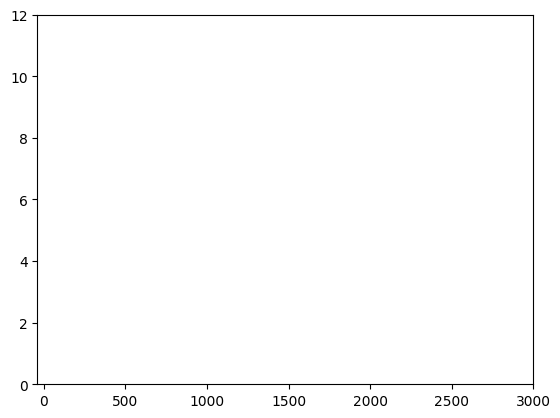

<Figure size 640x480 with 0 Axes>

In [12]:
plt.xlim(-40, 3000)
plt.ylim(0, 12)

fig = plt.figure()

metadata = dict(title='Live Load Lateral Surcharge Demo', artist='Dane Parks')
writer = PillowWriter(fps=15, metadata = metadata)

xlist = []
ylist = []
max_list = []

H_n = 100 # Number of times to split the height of the wall

# Script consists of 3 primary loops, main one that writes individual frames into the gif file:
with writer.saving(fig, "Cooper's_E80_Analysis.gif", 100):
    # Second loop that performs an analysis at 'x' distance away from the wall, up to 2x the walls height in 100 increments
    for xval in np.linspace(H.magnitude*2, 0, 100):
        
        # Setup the dictionary to hold all the values for where the vertical checks will be performed:
        dict_keys = [height * units.ft for height in np.round(np.arange(0, H.magnitude + (H/H_n).magnitude, (H/H_n).magnitude), 1)]
        for value in dict_keys:
            graphing_values[value] = 0. * units('kips/ft^2')

        # Third loop that adds pressure for each point load defined in the cooper E80 Load definition: (This should be split into a different function)
        for distance, load in cooper_e80_loads:
            # Deterimine the values for this particular run:
            run_values = calc_sigma_h_values(load * units.kips, H, xval*units.ft + distance*units.ft, H_n)
        
            # Add the values to the values of all the previous runs
            for height, load in run_values.items():
                graphing_values[height] = graphing_values[height] + load
        
        xs, ys = list(), list()
        wall_pts = [(0,0),(0,H.magnitude),(-H.magnitude/20,H.magnitude),(-H.magnitude/20,0), (0,0)]
        
        # Draw in the wall
        ax.add_patch(mpatches.Polygon(wall_pts, color='grey'))
    
        # Run a loop to extract this frames values from the above function call results
        for value in graphing_values:
            ys.append(value.magnitude)
            xs.append(graphing_values[value].magnitude)
        
        # Create the plot
        fig = plt.plot(xs, ys, lw=1, linestyle='dotted')
        
        # Add annotations, rectangular wall shape and fill
        xmax, ymax = annot_max(xs, ys)
        print(f"max load when front axel is {xval:.2f} ft away from wall: {xmax:.2f} kips/ft^2 at a height of: {ymax:.2f}") # Debugging step for checking, can probably get removed at a later date
        max_list.append(xmax)
        plt.fill_between(xs, ys)
        plt.title(f"Lateral Surcharge at x = {xval:2f} feet from wall")
        plt.ylabel('$Height\ of\ Wall\ (ft)$')
        plt.xlabel('$\sigma_H$ $(kips/ft^2)$')
        ax.hlines(ys[::5], xs[::5], ymax, color='black')
        
        # Draw the wall being analyzed into the plot
        rectangle = plt.Rectangle((0,0), H, -1, fc='blue',ec="red")

        l.set_data(xs, ys)

        writer.grab_frame()
        plt.clf()

print(f"Abs max stress: {max(max_list)}")

In [13]:
calc_sigma_h_values(load * units.kips, H, 10*units.ft + distance*units.ft, H_n)

{10.0 <Unit('foot')>: 0.0 <Unit('kip ** 2 / foot ** 4')>,
 9.9 <Unit('foot')>: 8.020576142233935e-15 <Unit('kip ** 2 / foot ** 4')>,
 9.8 <Unit('foot')>: 3.2082082393507995e-14 <Unit('kip ** 2 / foot ** 4')>,
 9.7 <Unit('foot')>: 7.218385223779627e-14 <Unit('kip ** 2 / foot ** 4')>,
 9.6 <Unit('foot')>: 1.2832477484924586e-13 <Unit('kip ** 2 / foot ** 4')>,
 9.5 <Unit('foot')>: 2.005032951434596e-13 <Unit('kip ** 2 / foot ** 4')>,
 9.4 <Unit('foot')>: 2.8871741384928685e-13 <Unit('kip ** 2 / foot ** 4')>,
 9.3 <Unit('foot')>: 3.929646876011177e-13 <Unit('kip ** 2 / foot ** 4')>,
 9.2 <Unit('foot')>: 5.132422290516713e-13 <Unit('kip ** 2 / foot ** 4')>,
 9.1 <Unit('foot')>: 6.495467070052759e-13 <Unit('kip ** 2 / foot ** 4')>,
 9.0 <Unit('foot')>: 8.018743465716239e-13 <Unit('kip ** 2 / foot ** 4')>,
 8.9 <Unit('foot')>: 9.702209293399941e-13 <Unit('kip ** 2 / foot ** 4')>,
 8.8 <Unit('foot')>: 1.1545817935739353e-12 <Unit('kip ** 2 / foot ** 4')>,
 8.7 <Unit('foot')>: 1.354951834426381